Saved figure to: ./jittor_vs_pytorch_total_loss.png


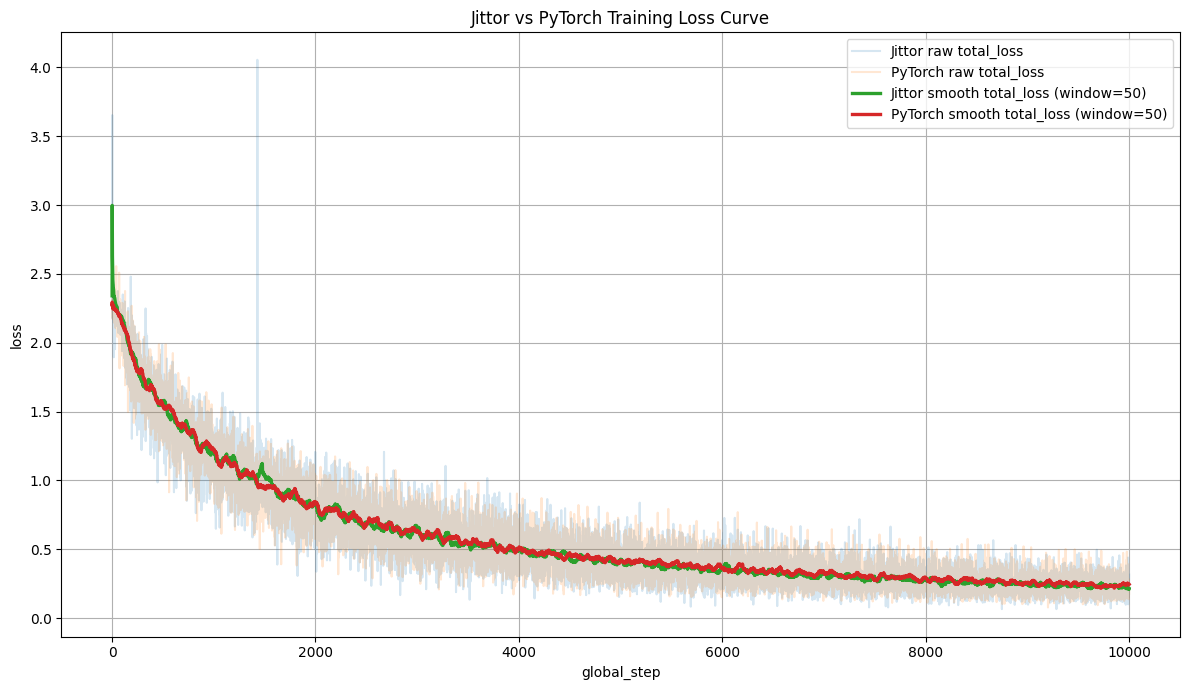

In [5]:
import os

import pandas as pd
import matplotlib.pyplot as plt


def load_and_prepare(csv_path, x_axis="global_step", smooth_window=50):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Log file not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_cols = [x_axis, "total_loss"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}' in: {csv_path}")

    # 丢掉关键列为空的行，避免画图报错
    df = df[[x_axis, "total_loss"]].dropna().copy()

    # 按 x 轴排序，防止曲线乱跳
    df = df.sort_values(by=x_axis).reset_index(drop=True)

    # 平滑
    df["total_loss_smooth"] = df["total_loss"].rolling(
        window=smooth_window, min_periods=1
    ).mean()

    return df


def main():
    jittor_log = "/media/wpc/jittor-retinanet/jittor-retinanet/logs/train_log.csv"
    pytorch_log = "/media/wpc/jittor-retinanet/pytorch-retinanet/logs/train_log.csv"

    output_png = "./jittor_vs_pytorch_total_loss.png"
    x_axis = "global_step"
    smooth_window = 50  # 可改成 50 / 200

    jittor_df = load_and_prepare(jittor_log, x_axis=x_axis, smooth_window=smooth_window)
    pytorch_df = load_and_prepare(pytorch_log, x_axis=x_axis, smooth_window=smooth_window)

    plt.figure(figsize=(12, 7))

    # 原始曲线
    plt.plot(
        jittor_df[x_axis],
        jittor_df["total_loss"],
        alpha=0.18,
        label="Jittor raw total_loss",
    )
    plt.plot(
        pytorch_df[x_axis],
        pytorch_df["total_loss"],
        alpha=0.18,
        label="PyTorch raw total_loss",
    )

    # 平滑曲线
    plt.plot(
        jittor_df[x_axis],
        jittor_df["total_loss_smooth"],
        linewidth=2.4,
        label=f"Jittor smooth total_loss (window={smooth_window})",
    )
    plt.plot(
        pytorch_df[x_axis],
        pytorch_df["total_loss_smooth"],
        linewidth=2.4,
        label=f"PyTorch smooth total_loss (window={smooth_window})",
    )

    plt.xlabel(x_axis)
    plt.ylabel("loss")
    plt.title("Jittor vs PyTorch Training Loss Curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_png, dpi=200)
    print(f"Saved figure to: {output_png}")
    plt.show()


if __name__ == "__main__":
    main()


===== Jittor Throughput Stats =====
Samples      : 10000
Mean         : 13.4147
Median       : 13.3100
Max          : 22.7800
Min          : 0.8300
Last         : 13.0500

===== PyTorch Throughput Stats =====
Samples      : 10000
Mean         : 10.7171
Median       : 10.6300
Max          : 16.5000
Min          : 1.7800
Last         : 10.5600

Jittor vs PyTorch mean throughput diff: 25.17%

Saved figure to: ./jittor_vs_pytorch_throughput.png


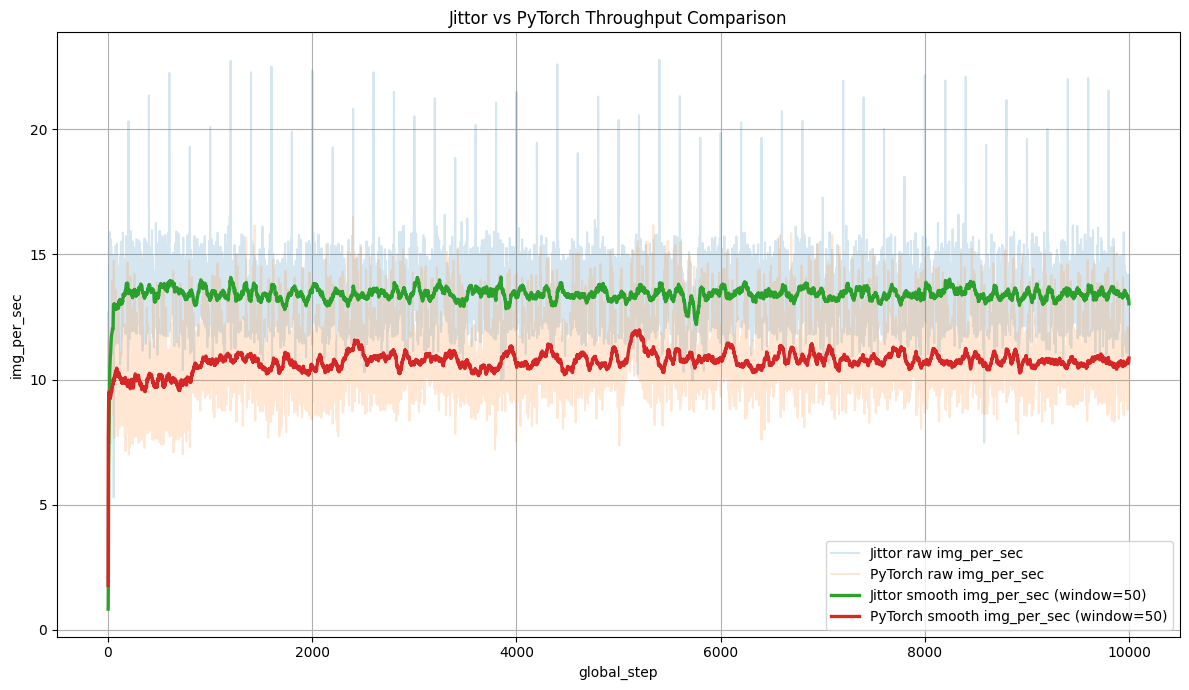

In [6]:
import os

import pandas as pd
import matplotlib.pyplot as plt


def load_and_prepare(csv_path, x_axis="global_step", y_axis="img_per_sec", smooth_window=50):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Log file not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_cols = [x_axis, y_axis]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}' in: {csv_path}")

    df = df[[x_axis, y_axis]].dropna().copy()
    df = df.sort_values(by=x_axis).reset_index(drop=True)

    df[f"{y_axis}_smooth"] = df[y_axis].rolling(
        window=smooth_window, min_periods=1
    ).mean()

    return df


def print_stats(name, df, y_axis="img_per_sec"):
    print(f"\n===== {name} Throughput Stats =====")
    print(f"Samples      : {len(df)}")
    print(f"Mean         : {df[y_axis].mean():.4f}")
    print(f"Median       : {df[y_axis].median():.4f}")
    print(f"Max          : {df[y_axis].max():.4f}")
    print(f"Min          : {df[y_axis].min():.4f}")
    print(f"Last         : {df[y_axis].iloc[-1]:.4f}")


def main():
    jittor_log = "/media/wpc/jittor-retinanet/jittor-retinanet/logs/train_log.csv"
    pytorch_log = "/media/wpc/jittor-retinanet/pytorch-retinanet/logs/train_log.csv"

    output_png = "./jittor_vs_pytorch_throughput.png"
    x_axis = "global_step"
    y_axis = "img_per_sec"
    smooth_window = 50

    jittor_df = load_and_prepare(
        jittor_log, x_axis=x_axis, y_axis=y_axis, smooth_window=smooth_window
    )
    pytorch_df = load_and_prepare(
        pytorch_log, x_axis=x_axis, y_axis=y_axis, smooth_window=smooth_window
    )

    print_stats("Jittor", jittor_df, y_axis=y_axis)
    print_stats("PyTorch", pytorch_df, y_axis=y_axis)

    jittor_mean = jittor_df[y_axis].mean()
    pytorch_mean = pytorch_df[y_axis].mean()

    if pytorch_mean != 0:
        diff_pct = (jittor_mean - pytorch_mean) / pytorch_mean * 100
        print(f"\nJittor vs PyTorch mean throughput diff: {diff_pct:.2f}%")

    plt.figure(figsize=(12, 7))

    # 原始曲线
    plt.plot(
        jittor_df[x_axis],
        jittor_df[y_axis],
        alpha=0.18,
        label="Jittor raw img_per_sec",
    )
    plt.plot(
        pytorch_df[x_axis],
        pytorch_df[y_axis],
        alpha=0.18,
        label="PyTorch raw img_per_sec",
    )

    # 平滑曲线
    plt.plot(
        jittor_df[x_axis],
        jittor_df[f"{y_axis}_smooth"],
        linewidth=2.4,
        label=f"Jittor smooth img_per_sec (window={smooth_window})",
    )
    plt.plot(
        pytorch_df[x_axis],
        pytorch_df[f"{y_axis}_smooth"],
        linewidth=2.4,
        label=f"PyTorch smooth img_per_sec (window={smooth_window})",
    )

    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.title("Jittor vs PyTorch Throughput Comparison")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_png, dpi=200)
    print(f"\nSaved figure to: {output_png}")
    plt.show()


if __name__ == "__main__":
    main()


===== Jittor GPU Memory Stats =====
Samples      : 10000
Mean         : 19933.2958 MB
Median       : 19987.0000 MB
Max          : 24227.0000 MB
Min          : 13073.0000 MB
Last         : 19989.0000 MB

===== PyTorch GPU Memory Stats =====
Samples      : 10000
Mean         : 11993.8202 MB
Median       : 12009.0000 MB
Max          : 12009.0000 MB
Min          : 8935.0000 MB
Last         : 12009.0000 MB

Mean memory diff (Jittor vs PyTorch): 66.20%
Peak memory diff (Jittor vs PyTorch): 101.74%

Saved figure to: ./jittor_vs_pytorch_gpu_mem.png


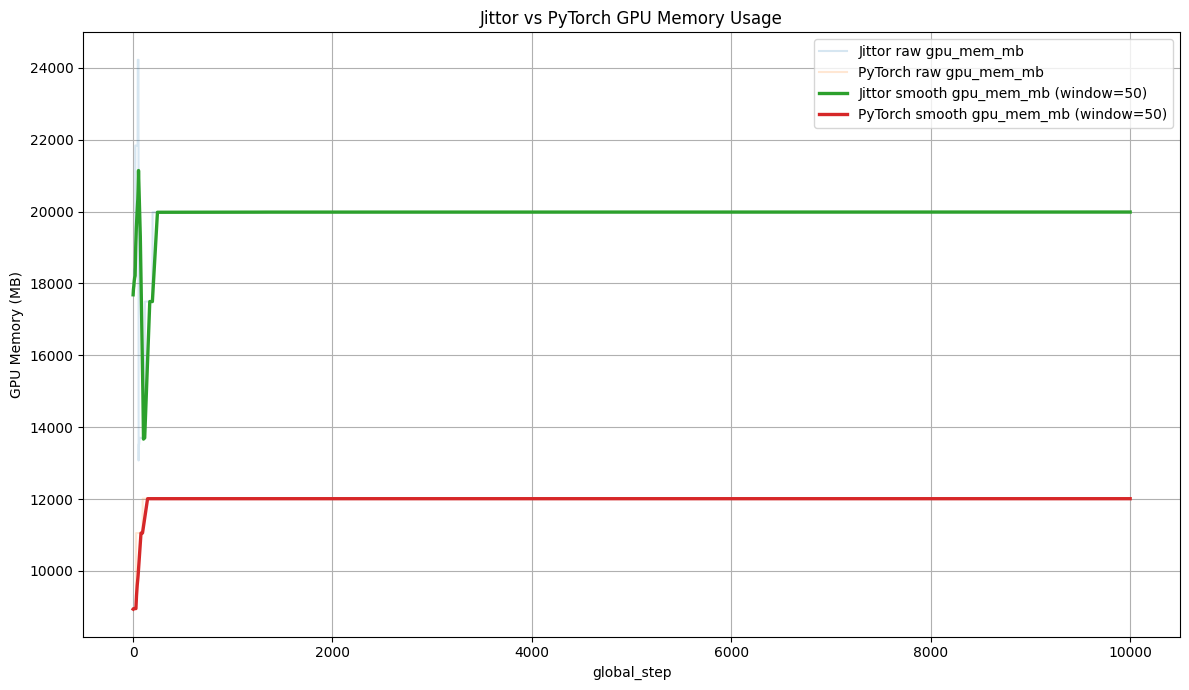

In [7]:
import os

import pandas as pd
import matplotlib.pyplot as plt


def load_and_prepare(csv_path, x_axis="global_step", y_axis="gpu_mem_mb", smooth_window=50):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Log file not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_cols = [x_axis, y_axis]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}' in: {csv_path}")

    df = df[[x_axis, y_axis]].dropna().copy()
    df = df.sort_values(by=x_axis).reset_index(drop=True)

    df[f"{y_axis}_smooth"] = df[y_axis].rolling(
        window=smooth_window, min_periods=1
    ).mean()

    return df


def print_stats(name, df, y_axis="gpu_mem_mb"):
    print(f"\n===== {name} GPU Memory Stats =====")
    print(f"Samples      : {len(df)}")
    print(f"Mean         : {df[y_axis].mean():.4f} MB")
    print(f"Median       : {df[y_axis].median():.4f} MB")
    print(f"Max          : {df[y_axis].max():.4f} MB")
    print(f"Min          : {df[y_axis].min():.4f} MB")
    print(f"Last         : {df[y_axis].iloc[-1]:.4f} MB")


def main():
    jittor_log = "/media/wpc/jittor-retinanet/jittor-retinanet/logs/train_log.csv"
    pytorch_log = "/media/wpc/jittor-retinanet/pytorch-retinanet/logs/train_log.csv"

    output_png = "./jittor_vs_pytorch_gpu_mem.png"
    x_axis = "global_step"
    y_axis = "gpu_mem_mb"
    smooth_window = 50

    jittor_df = load_and_prepare(
        jittor_log, x_axis=x_axis, y_axis=y_axis, smooth_window=smooth_window
    )
    pytorch_df = load_and_prepare(
        pytorch_log, x_axis=x_axis, y_axis=y_axis, smooth_window=smooth_window
    )

    print_stats("Jittor", jittor_df, y_axis=y_axis)
    print_stats("PyTorch", pytorch_df, y_axis=y_axis)

    jittor_mean = jittor_df[y_axis].mean()
    pytorch_mean = pytorch_df[y_axis].mean()
    jittor_peak = jittor_df[y_axis].max()
    pytorch_peak = pytorch_df[y_axis].max()

    if pytorch_mean != 0:
        mean_diff_pct = (jittor_mean - pytorch_mean) / pytorch_mean * 100
        print(f"\nMean memory diff (Jittor vs PyTorch): {mean_diff_pct:.2f}%")

    if pytorch_peak != 0:
        peak_diff_pct = (jittor_peak - pytorch_peak) / pytorch_peak * 100
        print(f"Peak memory diff (Jittor vs PyTorch): {peak_diff_pct:.2f}%")

    plt.figure(figsize=(12, 7))

    # 原始曲线
    plt.plot(
        jittor_df[x_axis],
        jittor_df[y_axis],
        alpha=0.18,
        label="Jittor raw gpu_mem_mb",
    )
    plt.plot(
        pytorch_df[x_axis],
        pytorch_df[y_axis],
        alpha=0.18,
        label="PyTorch raw gpu_mem_mb",
    )

    # 平滑曲线
    plt.plot(
        jittor_df[x_axis],
        jittor_df[f"{y_axis}_smooth"],
        linewidth=2.4,
        label=f"Jittor smooth gpu_mem_mb (window={smooth_window})",
    )
    plt.plot(
        pytorch_df[x_axis],
        pytorch_df[f"{y_axis}_smooth"],
        linewidth=2.4,
        label=f"PyTorch smooth gpu_mem_mb (window={smooth_window})",
    )

    plt.xlabel(x_axis)
    plt.ylabel("GPU Memory (MB)")
    plt.title("Jittor vs PyTorch GPU Memory Usage")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_png, dpi=200)
    print(f"\nSaved figure to: {output_png}")
    plt.show()


if __name__ == "__main__":
    main()

Saved figure to: ./jittor_vs_pytorch_val_metrics.png


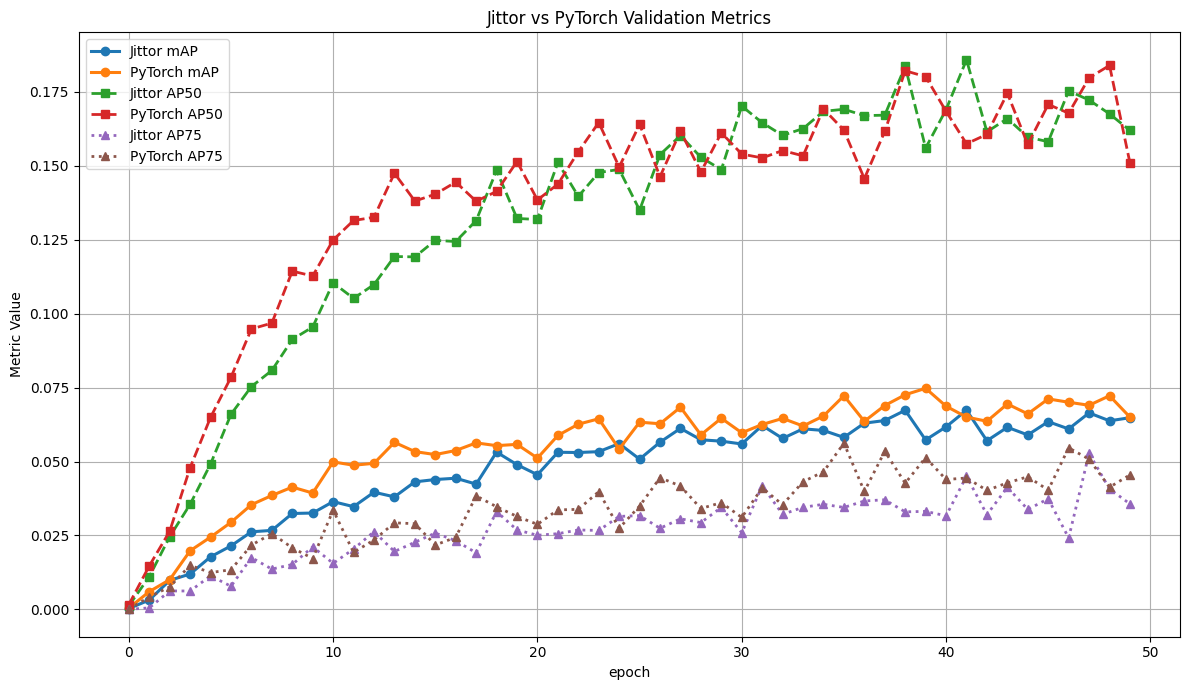

In [8]:
import os

import pandas as pd
import matplotlib.pyplot as plt


def load_and_prepare(csv_path, x_axis="epoch"):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Log file not found: {csv_path}")

    df = pd.read_csv(csv_path)

    required_cols = ["mAP", "AP50", "AP75", x_axis]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}' in: {csv_path}")

    df = df[[x_axis, "mAP", "AP50", "AP75"]].dropna().copy()
    df = df.sort_values(by=x_axis).reset_index(drop=True)
    return df


def main():
    jittor_log = "/media/wpc/jittor-retinanet/jittor-retinanet/logs/val_log.csv"
    pytorch_log = "/media/wpc/jittor-retinanet/pytorch-retinanet/logs/val_log.csv"

    output_png = "./jittor_vs_pytorch_val_metrics.png"
    x_axis = "epoch"

    jittor_df = load_and_prepare(jittor_log, x_axis=x_axis)
    pytorch_df = load_and_prepare(pytorch_log, x_axis=x_axis)

    plt.figure(figsize=(12, 7))

    # mAP
    plt.plot(
        jittor_df[x_axis], jittor_df["mAP"],
        marker="o", linewidth=2.2, label="Jittor mAP"
    )
    plt.plot(
        pytorch_df[x_axis], pytorch_df["mAP"],
        marker="o", linewidth=2.2, label="PyTorch mAP"
    )

    # AP50
    plt.plot(
        jittor_df[x_axis], jittor_df["AP50"],
        marker="s", linewidth=2.0, linestyle="--", label="Jittor AP50"
    )
    plt.plot(
        pytorch_df[x_axis], pytorch_df["AP50"],
        marker="s", linewidth=2.0, linestyle="--", label="PyTorch AP50"
    )

    # AP75
    plt.plot(
        jittor_df[x_axis], jittor_df["AP75"],
        marker="^", linewidth=2.0, linestyle=":", label="Jittor AP75"
    )
    plt.plot(
        pytorch_df[x_axis], pytorch_df["AP75"],
        marker="^", linewidth=2.0, linestyle=":", label="PyTorch AP75"
    )

    plt.xlabel(x_axis)
    plt.ylabel("Metric Value")
    plt.title("Jittor vs PyTorch Validation Metrics")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_png, dpi=200)
    print(f"Saved figure to: {output_png}")
    plt.show()


if __name__ == "__main__":
    main()